# Ca data: second-order geometric affine line fit

Fit the Ca concentration series using one positive Gaussian radial \(k\) distribution and an incompressible uniaxial stretch. The fourth data column is treated as the pointwise Gaussian resolution standard deviation \(\sigma_Q\).

The nonlinear parameters are \(\langle k\rangle\), the relative Gaussian width, and the real-space axial stretch. For each trial isotropic line spectrum, the workflow samples the density--tangent and tangent--tangent correlations and assembles the physical-arclength powder spectrum through second order in the incompressible Hencky strain. The scalar spectral-remapping implementation remains available as a selectable comparison model.

The resulting unsmeared powder curve is convolved with the measured pointwise resolution before its scale and regression loss are evaluated.

In [1]:
from pathlib import Path
import csv
import re

import matplotlib.pyplot as plt
import numpy as np

import cf_tools as cf

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

def salt_concentration_mM(path):
    name = Path(path).name
    if re.search(r"D2O", name, flags=re.IGNORECASE):
        return 0.0
    match = re.search(r"(?P<value>\d+(?:\.\d+)?)mM(?:Ca)?IQ", name, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(f"Cannot parse Ca concentration from {name!r}")
    return float(match.group("value"))

def load_grasp_iq(path):
    rows = []
    for line in Path(path).read_text(encoding="utf-8", errors="replace").splitlines():
        fields = line.split()
        if len(fields) != 4:
            continue
        try:
            rows.append(tuple(float(value) for value in fields))
        except ValueError:
            continue
    table = np.asarray(rows, dtype=float)
    if table.ndim != 2 or table.shape[0] < 8 or table.shape[1] != 4:
        raise ValueError(f"Could not find a four-column Q, I, error, dQ table in {path}")
    return table

def save_affine_geometric_components(fit_result, path):
    geom = getattr(fit_result, "affine_geometric_result", None)
    if geom is None:
        return None
    np.savez(
        path,
        Q=geom.Q_grid,
        I_L=geom.I_L,
        I_scalar_exact=geom.I_scalar_exact,
        I_scalar_second_order=geom.I_scalar_second_order,
        I_geom_second_order=geom.I_geom_second_order,
        I_trho=geom.I_trho,
        I_tt=geom.I_tt,
        D_I_L=geom.D_I_L,
        D2_I_L=geom.D2_I_L,
        D_I_trho=geom.D_I_trho,
        r=geom.r_grid,
        C_L=geom.C_L,
        K_trho=geom.K_trho,
        K_tt=geom.K_tt,
        K_trho_baseline=geom.K_trho_baseline,
        K_tt_baseline=geom.K_tt_baseline,
        stretch_ratio=geom.stretch_ratio,
        hencky_strain=geom.hencky_strain,
        T_H=geom.T_H,
        k_eff=geom.k_eff,
        rho0=geom.rho0,
    )
    return Path(path)


## Select the dataset and affine model

The geometric second-order model is defined for the uniform physical line measure and therefore requires line-only mode. Set AFFINE_MODEL to scalar to recover the previous spectral-remapping workflow.

In [2]:
DATA_DIR = Path("data/Ca")
OUTPUT_DIR = Path("output/ca_aniso")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SERIES_KEY = "D2O"
MODEL_MODE = "line_only"
K_DISTRIBUTION = "gamma_radial"  # "gamma_radial" or "gaussian_radial"
K_SCALE_CONVENTION = "k_eff"
STRETCH_MODEL = "full_geom"  # "spectrum" or "full_geom"
FINE_TUNE_GEOM = True  # for full_geom, initialize each curve from its saved spectrum fit
DISTRIBUTION_UPPER_QUANTILE = 0.99999  # extend gamma P(k) until the upper tail is visually negligible
if STRETCH_MODEL not in {"spectrum", "full_geom"}:
    raise ValueError("STRETCH_MODEL must be spectrum or full_geom")
AFFINE_MODEL = {
    "spectrum": "scalar",
    "full_geom": "geometric_second_order",
}[STRETCH_MODEL]
LOCK_SALT_FEATURE_TO_D2O = False
REFERENCE_K_EFF_OVERRIDE = None  # optional manual value in A^-1

FIT_Q_MIN = 6.0e-3
FIT_Q_MAX = 4.0e-1
HIGHQ_ANCHOR_MIN = 2.0e-1
SUBTRACT_BG = True
HIGHQ_ANCHOR_WEIGHT = 1.0
LOG_ERROR_FLOOR = 0.04

CONSTRAINT_SETTINGS = {
    "line_density": {
        "enabled": True,
        "reference_density": 2.998586541845732e-4,  # A^-2, unconstrained D2O
        "relative_sigma": 0.06,  
        "penalty_mode": "below_reference_only",  # "two_sided" or "below_reference_only"
    },
    "k_eff_lower_barrier": {
        "enabled": False,
        "lower": 0.035,
        "cutoff": 0.045,
        "strength": 1.0,
        "epsilon_fraction": 0.5,
    },
}
FIT_GUIDANCE_TAG = f"unguided_{K_DISTRIBUTION}_{STRETCH_MODEL}_OH2"
SPECTRUM_FIT_GUIDANCE_TAG = f"unguided_{K_DISTRIBUTION}_spectrum_OH2"
GEOM_FINE_TUNE_ACTIVE = bool(FINE_TUNE_GEOM and STRETCH_MODEL == "full_geom")

# Forward resolution smearing. The fourth data column is sigma_Q.
SMEAR_MODEL = True

files = sorted(DATA_DIR.glob("*.dat"), key=lambda path: salt_concentration_mM(path))
if not files:
    raise FileNotFoundError(f"No .dat files found under {DATA_DIR}")

SERIES = {}
for path in files:
    concentration = salt_concentration_mM(path)
    key = "D2O" if concentration == 0.0 else f"{concentration:g}mM"
    if key in SERIES:
        raise ValueError(f"Duplicate CA series key {key!r}")
    SERIES[key] = {"file": path, "concentration_mM": concentration}

if SERIES_KEY not in SERIES:
    raise KeyError(f"SERIES_KEY must be one of {tuple(SERIES)}")
if MODEL_MODE not in {"heterogeneous", "line_only"}:
    raise ValueError("MODEL_MODE must be 'heterogeneous' or 'line_only'")
if K_DISTRIBUTION not in {"gamma_radial", "gaussian_radial"}:
    raise ValueError("K_DISTRIBUTION must be gamma_radial or gaussian_radial")
if AFFINE_MODEL not in {"scalar", "geometric_second_order"}:
    raise ValueError("AFFINE_MODEL must be scalar or geometric_second_order")
if AFFINE_MODEL == "geometric_second_order" and MODEL_MODE != "line_only":
    raise ValueError("geometric_second_order currently requires MODEL_MODE=line_only")

config = SERIES[SERIES_KEY]
DATA_FILE = config["file"]
SALT_MILLIMOLAR = float(config["concentration_mM"])
IS_SALT_FREE = SALT_MILLIMOLAR == 0.0
SAMPLE_TAG = "ca_D2O" if IS_SALT_FREE else f"ca_{SALT_MILLIMOLAR:g}mM"
SERIES_LABEL = "D2O (0 mM Ca)" if IS_SALT_FREE else f"{SALT_MILLIMOLAR:g} mM Ca"
CF_MODEL_MODE = MODEL_MODE
FIT_VARIANT_TAG = f"{MODEL_MODE}_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}"

print("[series]", {key: item["file"].name for key, item in SERIES.items()})
print(f"[status] selected={SERIES_LABEL}, mode={MODEL_MODE}, stretch={STRETCH_MODEL}, affine={AFFINE_MODEL}, k_distribution={K_DISTRIBUTION}, fine_tune_geom={GEOM_FINE_TUNE_ACTIVE}")
print(f"[status] data={DATA_FILE}")

[series] {'D2O': 'PSS_67K_D2OIQ_362051_d01_c01.dat', '1mM': 'PSS_67K_1mMCaIQ_362054_d04_c01.dat', '10mM': 'PSS_67K_10mMCaIQ_362053_d03_c01.dat', '24mM': 'PSS_67k_24mMCaIQ_362130_d01_c01.dat', '40mM': 'PSS_67K_40mMCaIQ_362691_d03_c01.dat', '55mM': 'PSS_67K_55mMCaIQ_362673_d02_c01.dat', '70mM': 'PSS_67k_70mMCaIQ_362692_d04_c01.dat', '100mM': 'PSS_67K_100mMCaIQ_362052_d02_c01.dat'}
[status] selected=D2O (0 mM Ca), mode=line_only, stretch=full_geom, affine=geometric_second_order, k_distribution=gamma_radial, fine_tune_geom=True
[status] data=data\Ca\PSS_67K_D2OIQ_362051_d01_c01.dat


## Load and inspect the complete concentration series

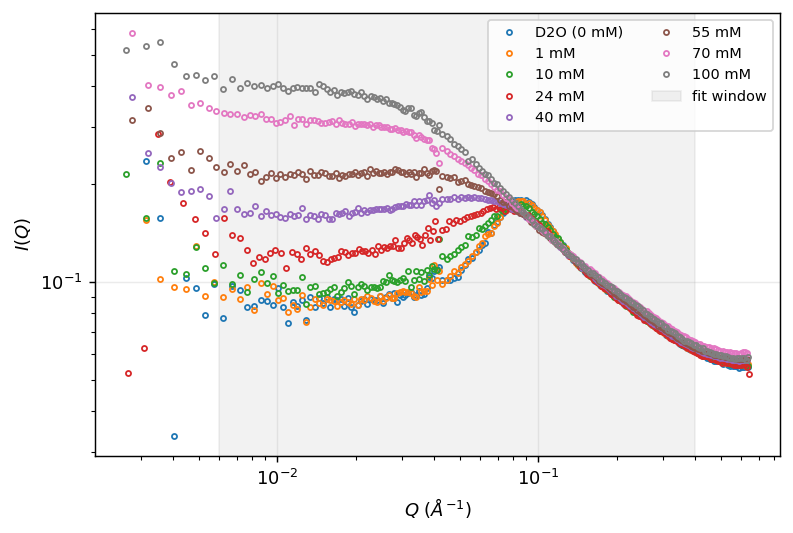

[status] loaded 186 measured points; fit Q=[0.006, 0.4]
[resolution] forward model smearing=enabled
[resolution] convolution support Q=[0.00264865, 0.636162]; regression loss Q=[0.006, 0.4]


In [3]:
all_tables = {key: load_grasp_iq(item["file"]) for key, item in SERIES.items()}
table = all_tables[SERIES_KEY]
q, intensity, error, dq = (np.asarray(table[:, col], dtype=float) for col in range(4))
good = np.isfinite(q) & np.isfinite(intensity) & np.isfinite(error) & np.isfinite(dq) & (q > 0) & (error > 0) & (dq > 0)
order = np.argsort(q[good])
q, intensity, error, dq = (array[good][order] for array in (q, intensity, error, dq))

profile = cf.RadialProfile(
    label=SAMPLE_TAG,
    q=q,
    intensity=intensity,
    error=error,
    count=np.ones(q.size, dtype=int),
)
fit_q_min = max(float(q.min()), FIT_Q_MIN)
fit_q_max = min(float(q.max()), FIT_Q_MAX)
HIGHQ_ANCHOR_BOUNDS = (max(HIGHQ_ANCHOR_MIN, fit_q_min), fit_q_max)
regression_weights = np.ones_like(q)

np.savetxt(
    OUTPUT_DIR / f"{SAMPLE_TAG}_observation.csv",
    np.column_stack([q, intensity, error, dq]),
    delimiter=",",
    header="Q,I,err,dQ",
    comments="",
)

fig, ax = plt.subplots(figsize=(6.2, 4.2))
for key, item in SERIES.items():
    values = all_tables[key]
    positive = values[:, 1] > 0
    label = "D2O (0 mM)" if item["concentration_mM"] == 0 else f"{item['concentration_mM']:g} mM"
    ax.loglog(values[positive, 0], values[positive, 1], "o", ms=2.8, markerfacecolor="none", label=label)
ax.axvspan(fit_q_min, fit_q_max, color="k", alpha=0.05, label="fit window")
ax.set_xlabel(r"$Q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(Q)$")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ca_raw_series.png")
plt.show()
print(f"[status] loaded {q.size} measured points; fit Q=[{fit_q_min:.6g}, {fit_q_max:.6g}]")
print(f"[resolution] forward model smearing={'enabled' if SMEAR_MODEL else 'disabled'}")
if SMEAR_MODEL:
    print(f"[resolution] convolution support Q=[{q.min():.6g}, {q.max():.6g}]; regression loss Q=[{fit_q_min:.6g}, {fit_q_max:.6g}]")

## Background and high-$Q$ line anchor

Only the high-$Q$ $C/Q+B$ anchor is used. The low-$Q$ upturn is assumed negligible, so no DAB or $Q^{-4}$ anchor enters the fit.

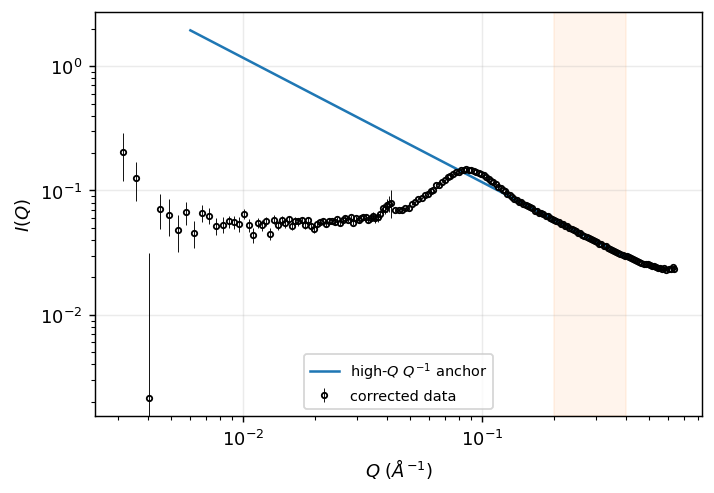

[background] subtracted B=0.031463713
[anchor] high-Q coefficient=0.011625399


In [4]:
raw_highq_fit = cf.fit_highq_line_anchor(profile, HIGHQ_ANCHOR_BOUNDS, allow_signed_background=True)
background_subtracted = raw_highq_fit.parameters["background"] if SUBTRACT_BG else 0.0
working_profile = cf.subtract_constant_background(profile, background_subtracted) if SUBTRACT_BG else profile
highq_line_fit = cf.fit_highq_line_anchor(
    working_profile,
    HIGHQ_ANCHOR_BOUNDS,
    background_max=0.0 if SUBTRACT_BG else None,
)

np.savetxt(
    OUTPUT_DIR / f"{SAMPLE_TAG}_background_corrected_observation.csv",
    cf.profile_table(working_profile),
    delimiter=",",
    header="Q,I,err,count",
    comments="",
)
with (OUTPUT_DIR / f"{SAMPLE_TAG}_anchor_guesses.csv").open("w", newline="", encoding="utf-8") as handle:
    writer = csv.writer(handle)
    writer.writerow(["name", "value_1", "value_2", "background", "relative_rmse"])
    writer.writerow(["subtracted_background", background_subtracted, np.nan, np.nan, np.nan])
    writer.writerow(["highQ_line", highq_line_fit.parameters["coefficient"], highq_line_fit.parameters["rho0_apparent"], highq_line_fit.parameters["background"], highq_line_fit.relative_rmse])

positive = working_profile.intensity > 0
q_grid = np.geomspace(fit_q_min, fit_q_max, 500)
fig, ax = plt.subplots(figsize=(5.6, 3.9))
ax.errorbar(working_profile.q[positive], working_profile.intensity[positive], yerr=working_profile.error[positive], fmt="o", ms=3, lw=0.5, color="k", markerfacecolor="none", label="corrected data")
ax.plot(q_grid, cf.evaluate_anchor_fit(highq_line_fit, q_grid), lw=1.4, label=r"high-$Q$ $Q^{-1}$ anchor")
ax.axvspan(*HIGHQ_ANCHOR_BOUNDS, color="C1", alpha=0.08)
ax.set(xscale="log", yscale="log", xlabel=r"$Q$ ($\AA^{-1}$)", ylabel=r"$I(Q)$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_highq_anchor.png")
plt.show()
print(f"[background] subtracted B={background_subtracted:.8g}")
print(f"[anchor] high-Q coefficient={highq_line_fit.parameters['coefficient']:.8g}")

## Centralized fit controls

Each parameter has one row containing its initial value, bounds, and fixed/free state. The affine implementation is selected separately by AFFINE_MODEL. The geometric model evaluates \(K_{t\rho}\) and \(K_{tt}\) from common 12-dimensional samples for every nonlinear trial.

In [5]:
# Edit this table while manually tuning the D2O initial model.
# For gamma_radial, k_eff=sqrt(<k^2>) and r_sigma_k=sigma_k/<k>.
PARAMETERS = {
    "k_eff":        {"initial": 0.05, "bounds": (0.010, 0.50), "fixed": False},
    "r_sigma_k":    {"initial": 0.17,  "bounds": (0.03, 1.20),  "fixed": False},
    "stretch_ratio": {"initial": 1.3,  "bounds": (1.1, 3.0),   "fixed": False},
    "k_H_over_k":   {"initial": 1e-5,  "bounds": (1e-6, 1e-2),  "fixed": True},
    "b":            {"initial": -2.0,  "bounds": (-4.0, -0.5), "fixed": True},
}

# Width initialization. Each distribution uses its own SVD calibration;
# the multiplier is applied consistently to the selected and batch seeds.
WIDTH_SEED_MULTIPLIER = 0.6

def load_saved_fit_parameters(path):
    with path.open(newline="", encoding="utf-8") as handle:
        return {row["name"]: float(row["value"]) for row in csv.DictReader(handle)}

def find_spectrum_fit_parameters(sample_tag, concentration_mM):
    tags = [sample_tag, f"ca_{float(concentration_mM):g}mM"]
    checked = []
    for tag in dict.fromkeys(tags):
        path = OUTPUT_DIR / f"{tag}_{K_DISTRIBUTION}_{SPECTRUM_FIT_GUIDANCE_TAG}_fit_parameters.csv"
        checked.append(path)
        if path.exists():
            return path, load_saved_fit_parameters(path)
    raise FileNotFoundError(
        "Geometric fine tuning requires an existing spectrum fit; checked "
        + ", ".join(str(path) for path in checked)
    )

svd1_width = None
selected_fine_tune_path = None
if GEOM_FINE_TUNE_ACTIVE:
    selected_fine_tune_path, selected_fine_tune_values = find_spectrum_fit_parameters(
        SAMPLE_TAG, SALT_MILLIMOLAR
    )
    for name, specification in PARAMETERS.items():
        if name not in selected_fine_tune_values or specification["fixed"]:
            continue
        value = float(selected_fine_tune_values[name])
        lower, upper = map(float, specification["bounds"])
        if not lower <= value <= upper:
            raise ValueError(
                f"Saved spectrum {name}={value} is outside geometric bounds {(lower, upper)}"
            )
        specification["initial"] = value
    print(f"[geometric fine tune] selected seed={selected_fine_tune_path}")
else:
    svd1_width = cf.estimate_k_distribution_width_svd1(
        working_profile.q,
        working_profile.intensity,
        PARAMETERS["k_eff"]["initial"],
        q_range=(fit_q_min, fit_q_max),
        k_distribution=K_DISTRIBUTION,
    )
    PARAMETERS["r_sigma_k"]["initial"] = (
        WIDTH_SEED_MULTIPLIER * svd1_width.r_sigma_k
    )
    print(f"[{K_DISTRIBUTION} SVD1 width seed]", svd1_width)

REFERENCE_PARAMETER_FILE = OUTPUT_DIR / f"ca_D2O_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_parameters.csv"
reference_k_eff = REFERENCE_K_EFF_OVERRIDE
if not IS_SALT_FREE and LOCK_SALT_FEATURE_TO_D2O and reference_k_eff is None:
    if not REFERENCE_PARAMETER_FILE.exists():
        raise FileNotFoundError(
            f"Fit D2O first or set REFERENCE_K_EFF_OVERRIDE; missing {REFERENCE_PARAMETER_FILE}"
        )
    reference_values = {}
    with REFERENCE_PARAMETER_FILE.open(newline="", encoding="utf-8") as handle:
        for row in csv.DictReader(handle):
            reference_values[row["name"]] = float(row["value"])
    reference_k_eff = reference_values["k_eff"]

if not IS_SALT_FREE and LOCK_SALT_FEATURE_TO_D2O:
    PARAMETERS["k_eff"]["initial"] = float(reference_k_eff)
    PARAMETERS["k_eff"]["fixed"] = True

distribution_names = ["r_sigma_k"]
active_names = ["k_eff", *distribution_names, "stretch_ratio"]
if CF_MODEL_MODE == "heterogeneous":
    active_names += ["k_H_over_k", "b"]
fit_initial = {name: float(PARAMETERS[name]["initial"]) for name in active_names}
fit_bounds = {name: tuple(map(float, PARAMETERS[name]["bounds"])) for name in active_names}
FIXED_PARAMETERS = {name: fit_initial[name] for name in active_names if PARAMETERS[name]["fixed"]}
barrier_settings = CONSTRAINT_SETTINGS["k_eff_lower_barrier"]
KEFF_LOWER_BARRIERS = (
    {"k_eff": (
        float(barrier_settings["lower"]),
        float(barrier_settings["cutoff"]),
        float(barrier_settings["strength"]),
        float(barrier_settings["epsilon_fraction"]),
    )}
    if barrier_settings["enabled"]
    else {}
)
density_settings = CONSTRAINT_SETTINGS["line_density"]
density_reference = None
LINE_DENSITY_ANCHOR = None
if density_settings["enabled"]:
    density_reference = float(density_settings["reference_density"])
    LINE_DENSITY_ANCHOR = (
        density_reference,
        float(density_settings["relative_sigma"]),
    )
BASE_FIT_CONSTRAINTS = cf.LineFitConstraints(
    inverse_square_lower_barriers=KEFF_LOWER_BARRIERS,
    line_density_anchor=LINE_DENSITY_ANCHOR,
    line_density_anchor_mode=str(density_settings.get("penalty_mode", "two_sided")),
)
FIT_CONSTRAINTS = BASE_FIT_CONSTRAINTS.with_fixed_parameters(FIXED_PARAMETERS)

fit_distribution_parameter_set = {
    name: {"initial": fit_initial[name], "bounds": fit_bounds[name]}
    for name in distribution_names
}
fit_model_settings = {
    "k_distribution": K_DISTRIBUTION,
    "k_scale_convention": K_SCALE_CONVENTION,
    "regression_loss": "relative",
    "num_modes_k": 2**9,
    "k_sampling": "quadrature",
    "Nr": 2700,
    "Nr_small": 600,
    "N_samp_U": 2**12,
    "N_samp_st": 2**7,
    "NQ": 220,
    "r_min_factor": 1e-3,
    "r_split_factor": 5.0,
    "r_max_factor": 250.0,
    "powder_n_mu": 64,
    "affine_model": AFFINE_MODEL,
    "N_samp_tangent": 2**12,
    "tangent_use_qmc": True,
    "tangent_random_seed": 12345,
    "derivative_smoothing_fraction": 1e-2,
    "tangent_tail_start_factor": 40.0,
    "tangent_tail_end_factor": 80.0,
    "progress": False,
}

if K_DISTRIBUTION == "gamma_radial":
    distribution_seed = cf.gamma_radial_parameters_from_k_eff(
        fit_initial["k_eff"], fit_initial["r_sigma_k"]
    )
else:
    distribution_seed = cf.gaussian_radial_parameters_from_k_eff(
        fit_initial["k_eff"], fit_initial["r_sigma_k"]
    )


def selected_radial_k_density(k_eff, r_sigma_k):
    if K_DISTRIBUTION == "gamma_radial":
        return cf.gamma_radial_density_from_k_eff(
            k_eff, r_sigma_k, upper_quantile=DISTRIBUTION_UPPER_QUANTILE,
        )
    return cf.gaussian_radial_density_from_k_eff(
        k_eff, r_sigma_k, upper_quantile=DISTRIBUTION_UPPER_QUANTILE,
    )
print(f"[affine model] {AFFINE_MODEL}")
print("[parameters]")
for name in active_names:
    state = "fixed" if name in FIXED_PARAMETERS else "free"
    print(f"  {name:16s} initial={fit_initial[name]:.8g} bounds={fit_bounds[name]} {state}")
print(f"[{K_DISTRIBUTION} seed]", distribution_seed)
print('[constraints]')
print(f"  k_eff lower barrier: {KEFF_LOWER_BARRIERS or 'disabled'}")
if LINE_DENSITY_ANCHOR is None:
    print('  line density anchor: disabled')
else:
    print(f"  line density anchor: {density_reference:.8g} A^-2, "
          f"relative sigma={LINE_DENSITY_ANCHOR[1]:.4g}, "
          f"mode={BASE_FIT_CONSTRAINTS.line_density_anchor_mode}")
if reference_k_eff is not None:
    print(f"[reference] k_eff={reference_k_eff:.8g} A^-1, wavelength={2*np.pi/reference_k_eff:.8g} A")


[geometric fine tune] selected seed=output\ca_aniso\ca_0mM_gamma_radial_unguided_gamma_radial_spectrum_OH2_fit_parameters.csv
[affine model] geometric_second_order
[parameters]
  k_eff            initial=0.052878396 bounds=(0.01, 0.5) free
  r_sigma_k        initial=0.16529885 bounds=(0.03, 1.2) free
  stretch_ratio    initial=1.2499285 bounds=(1.1, 3.0) free
[gamma_radial seed] {'k_eff': 0.052878395669387304, 'mean_k': 0.052170453814269734, 'sigma_k': 0.008623715984506144, 'gamma_shape': 36.59825166551815, 'gamma_scale': 0.0014254903291848575}
[constraints]
  k_eff lower barrier: disabled
  line density anchor: 0.00029985865 A^-2, relative sigma=0.06, mode=below_reference_only


## Inspect the resolution-smeared initial geometric model

The unsmeared curve is the assembled physical-arclength powder spectrum. Resolution convolution is applied only after the geometric density--density, tangent--density, and tangent--tangent contributions have been combined.

[status] initial cost=34.5366
[affine components] saved output\ca_aniso\ca_D2O_line_only_gamma_radial_unguided_gamma_radial_full_geom_OH2_initial_components.npz
[status] p_H=1
[feature] wavelength=118.8233 A
[affine] model=geometric_second_order; stretch_ratio=1.2499285; transverse=0.89445279
[high-Q] log-log slope unsmeared=-1.0014, smeared=-1.0004


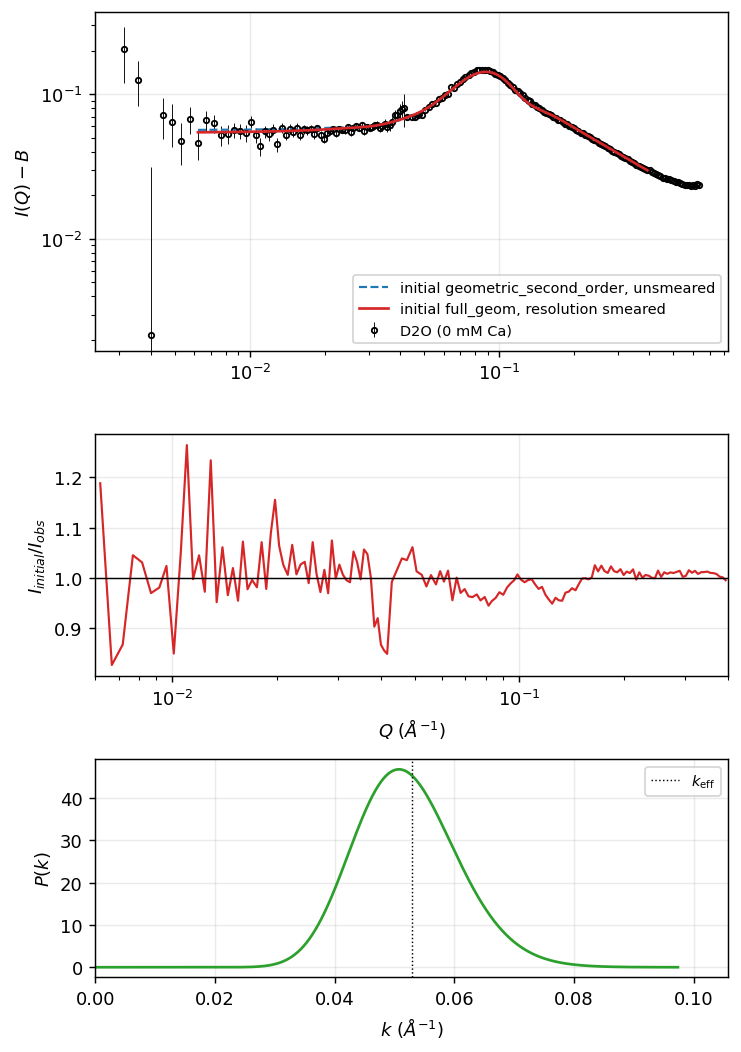

In [6]:
initial_model_unsmeared = cf.evaluate_heterogeneous_line_guess(
    working_profile,
    q_bounds=(fit_q_min, fit_q_max),
    parameters=fit_initial,
    model_mode=CF_MODEL_MODE,
    resolution_sigma=None,
    regression_weights=regression_weights,
    model_settings=fit_model_settings,
    distribution_parameter_set=fit_distribution_parameter_set,
    log_error_floor=LOG_ERROR_FLOOR,
    affine_stretch=True,
)
initial_model = cf.evaluate_heterogeneous_line_guess(
    working_profile,
    q_bounds=(fit_q_min, fit_q_max),
    parameters=fit_initial,
    model_mode=CF_MODEL_MODE,
    resolution_sigma=dq if SMEAR_MODEL else None,
    regression_weights=regression_weights,
    model_settings=fit_model_settings,
    distribution_parameter_set=fit_distribution_parameter_set,
    log_error_floor=LOG_ERROR_FLOOR,
    affine_stretch=True,
)
initial_components_path = save_affine_geometric_components(
    initial_model,
    OUTPUT_DIR / f"{SAMPLE_TAG}_{FIT_VARIANT_TAG}_initial_components.npz",
)
print(f"[status] initial cost={initial_model.cost:.6g}")
if initial_components_path is not None:
    print(f"[affine components] saved {initial_components_path}")
print(f"[status] p_H={initial_model.parameters['p_H']:.10g}")
print(f"[feature] wavelength={2*np.pi/initial_model.parameters['k_eff']:.8g} A")
print(f"[affine] model={initial_model.affine_model}; stretch_ratio={initial_model.parameters['stretch_ratio']:.8g}; transverse={initial_model.parameters['stretch_ratio']**-0.5:.8g}")
tail = initial_model.q >= HIGHQ_ANCHOR_MIN
if np.count_nonzero(tail) >= 3:
    slope_unsmeared = np.polyfit(np.log(initial_model_unsmeared.q[tail]), np.log(initial_model_unsmeared.model[tail]), 1)[0]
    slope_smeared = np.polyfit(np.log(initial_model.q[tail]), np.log(initial_model.model[tail]), 1)[0]
    print(f"[high-Q] log-log slope unsmeared={slope_unsmeared:.4f}, smeared={slope_smeared:.4f}")

k_initial, p_k_initial = selected_radial_k_density(
    initial_model.parameters["k_eff"], initial_model.parameters["r_sigma_k"]
)
fig, axes = plt.subplots(3, 1, figsize=(5.8, 8.2), gridspec_kw={"height_ratios": [1.4, 1.0, 0.9]})
positive = working_profile.intensity > 0
axes[0].errorbar(working_profile.q[positive], working_profile.intensity[positive], yerr=working_profile.error[positive], fmt="o", ms=3, lw=0.5, color="k", markerfacecolor="none", label=SERIES_LABEL)
axes[0].plot(initial_model_unsmeared.q, initial_model_unsmeared.model, "--", color="C0", lw=1.2, label=f"initial {AFFINE_MODEL}, unsmeared")
axes[0].plot(initial_model.q, initial_model.model, color="C3", lw=1.5, label=f"initial {STRETCH_MODEL}, resolution smeared",zorder=5)
axes[0].set(xscale="log", yscale="log", ylabel=r"$I(Q)-B$")
axes[0].legend(fontsize=8)
axes[1].semilogx(initial_model.q, initial_model.model / initial_model.intensity, color="C3", lw=1.2)
axes[1].axhline(1.0, color="k", lw=0.8)
axes[1].set(xlabel=r"$Q$ ($\AA^{-1}$)", ylabel=r"$I_{initial}/I_{obs}$", xlim=(fit_q_min, fit_q_max))
axes[2].plot(k_initial, p_k_initial, color="C2", lw=1.5)
axes[2].axvline(initial_model.parameters["k_eff"], color="k", lw=0.8, ls=":", label=r"$k_{\rm eff}$")
axes[2].set(xlabel=r"$k$ ($\AA^{-1}$)", ylabel=r"$P(k)$", xlim=(0.0, 2.0 * initial_model.parameters["k_eff"]))
axes[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_{FIT_VARIANT_TAG}_initial.png")
plt.show()

## Single-stage affine fit

The fit optimizes $k_{\rm eff}$, $r_{\sigma k}$, and the incompressible stretch together. Set `STRETCH_MODEL="spectrum"` for affine remapping of the isotropic spectrum alone, or set `STRETCH_MODEL="full_geom"` for the geometric second-order correction. The full-geometric curve uses the exact scalar powder remapping as its baseline and adds $T_H[8I_L/15+4\mathcal D_Q\mathcal I_{t\rho}/15+2\mathcal I_{tt}/15]$, which is equivalent to the strict series through second order but avoids the numerically unstable $\mathcal D_Q^2I_L$ term. The remaining logarithmic derivative is evaluated directly under the radial integral. The tangent transforms use their even quadratic low-$Q$ limits through $Q/k_{\rm eff}=0.5$ and blend smoothly to the direct transforms at $Q/k_{\rm eff}=0.8$. All three real-space correlations are accumulated from one common 12-dimensional sample and cached; changing only the stretch requires only analytic reassembly of the additive terms.


In [7]:
import time

RUN_FIT = False
MAX_NFEV = 50
FIT_NUM_MODES_K = 2**9

if RUN_FIT:
    optimization_settings = dict(
        fit_model_settings,
        affine_model=AFFINE_MODEL,
        num_modes_k=FIT_NUM_MODES_K,
    )
    fit_start = time.perf_counter()
    optimized_fit = cf.fit_heterogeneous_line_least_squares(
        working_profile,
        q_bounds=(fit_q_min, fit_q_max),
        initial=fit_initial,
        model_mode=CF_MODEL_MODE,
        resolution_sigma=dq if SMEAR_MODEL else None,
        regression_weights=regression_weights,
        lowq_kappa_anchor=None,
        highq_coefficient_anchor=highq_line_fit.parameters["coefficient"],
        bounds=fit_bounds,
        model_settings=optimization_settings,
        distribution_parameter_set=fit_distribution_parameter_set,
        constraints=FIT_CONSTRAINTS,
        max_nfev=MAX_NFEV,
        anchor_weight=HIGHQ_ANCHOR_WEIGHT,
        log_error_floor=LOG_ERROR_FLOOR,
        affine_stretch=True,
    )
    fit_elapsed = time.perf_counter() - fit_start
    print(
        f"[single-stage {AFFINE_MODEL}] success={optimized_fit.success}, "
        f"nfev={optimized_fit.nfev}, cost={optimized_fit.cost:.6g}, "
        f"elapsed={fit_elapsed:.2f} s"
    )
    print(f"[single-stage {AFFINE_MODEL}] {optimized_fit.message}")

    line_fit = optimized_fit
    line_fit.parameters["feature_wavelength_A"] = 2 * np.pi / line_fit.parameters["k_eff"]
    line_fit.parameters["salt_concentration_mM"] = SALT_MILLIMOLAR
    line_fit.parameters["optimization_cost"] = optimized_fit.cost
    line_fit.parameters["optimization_seconds"] = fit_elapsed
    line_fit.parameters["optimization_nfev"] = optimized_fit.nfev
    for name, value in line_fit.parameters.items():
        print(f"  {name:28s} {value:.10g}")

    with (OUTPUT_DIR / f"{SAMPLE_TAG}_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_parameters.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.writer(handle)
        writer.writerow(["name", "value"])
        writer.writerows(line_fit.parameters.items())
    fit_components_path = save_affine_geometric_components(
        line_fit,
        OUTPUT_DIR / f"{SAMPLE_TAG}_{FIT_VARIANT_TAG}_fit_components.npz",
    )
    if fit_components_path is not None:
        print(f"[affine components] saved {fit_components_path}")
    np.savetxt(
        OUTPUT_DIR / f"{SAMPLE_TAG}_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_curve.csv",
        np.column_stack([line_fit.q, line_fit.intensity, line_fit.error, line_fit.model, line_fit.model / line_fit.intensity]),
        delimiter=",",
        header="Q,I_obs,err,I_fit_smeared,I_fit_smeared_over_I_obs",
        comments="",
    )
else:
    print("[status] fit not run; tune the centralized parameter table and inspect the initial model")


[status] fit not run; tune the centralized parameter table and inspect the initial model


In [8]:
if RUN_FIT:
    k_fit, p_k_fit = selected_radial_k_density(
        line_fit.parameters["k_eff"], line_fit.parameters["r_sigma_k"]
    )
    fig, axes = plt.subplots(3, 1, figsize=(5.8, 8.2), gridspec_kw={"height_ratios": [1.4, 1.0, 0.9]})
    axes[0].errorbar(line_fit.q, line_fit.intensity, yerr=line_fit.error, fmt="o", ms=3, lw=0.5, color="k", markerfacecolor="none", label=SERIES_LABEL)
    axes[0].plot(line_fit.q, line_fit.model, color="C3", lw=1.6, label=f"{STRETCH_MODEL}, resolution smeared")
    axes[0].set(xscale="log", yscale="log", ylabel=r"$I(Q)$")
    axes[0].legend(fontsize=8)
    axes[1].semilogx(line_fit.q, line_fit.model / line_fit.intensity, "o-", ms=3, lw=1)
    axes[1].axhline(1.0, color="k", lw=0.8)
    axes[1].set(xlabel=r"$Q$ ($\AA^{-1}$)", ylabel=r"$I_{fit}/I_{obs}$", xlim=(fit_q_min, fit_q_max))
    axes[2].plot(k_fit, p_k_fit, color="C2", lw=1.5)
    axes[2].axvline(line_fit.parameters["k_eff"], color="k", lw=0.8, ls=":", label=r"$k_{\rm eff}$")
    axes[2].set(xlabel=r"$k$ ($\AA^{-1}$)", ylabel=r"$P(k)$", xlim=(0.0, 2.0 * line_fit.parameters["k_eff"]))
    axes[2].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_{FIT_VARIANT_TAG}_fit.png")
    plt.show()

[batch selection] ['70mM', '100mM']
[batch fixed] none

[batch] fitting 70 mM Ca
[batch geometric fine tune] source=output\ca_aniso\ca_70mM_gamma_radial_unguided_gamma_radial_spectrum_OH2_fit_parameters.csv
[batch seed] k_eff=0.0388996, r_sigma_k=0.454547, bounds=(0.227273, 0.909094), stretch=2.0112 in (1.0, 3.0)


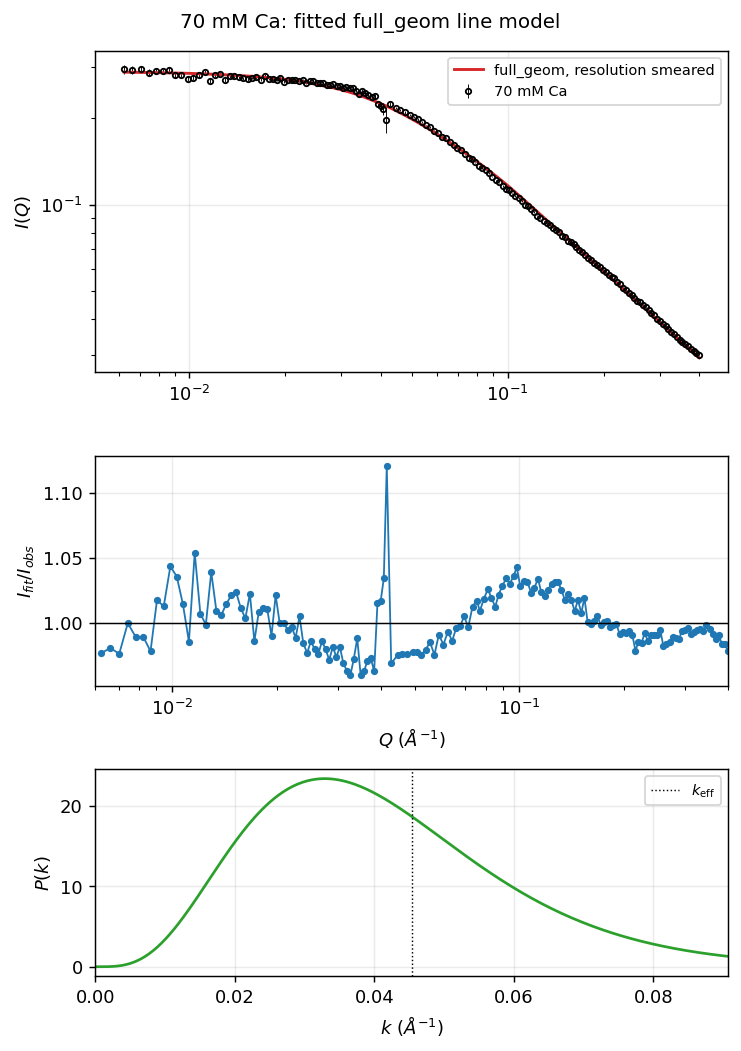

[batch figure] saved output\ca_aniso\ca_70mM_line_only_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit.png
[batch result] success=True, cost=20.6595, k_eff=0.0453509, r_sigma_k=0.451818, stretch=2.28144

[batch] fitting 100 mM Ca
[batch geometric fine tune] source=output\ca_aniso\ca_100mM_gamma_radial_unguided_gamma_radial_spectrum_OH2_fit_parameters.csv
[batch seed] k_eff=0.0289615, r_sigma_k=0.441313, bounds=(0.220657, 0.882627), stretch=1.94633 in (1.0, 3.0)


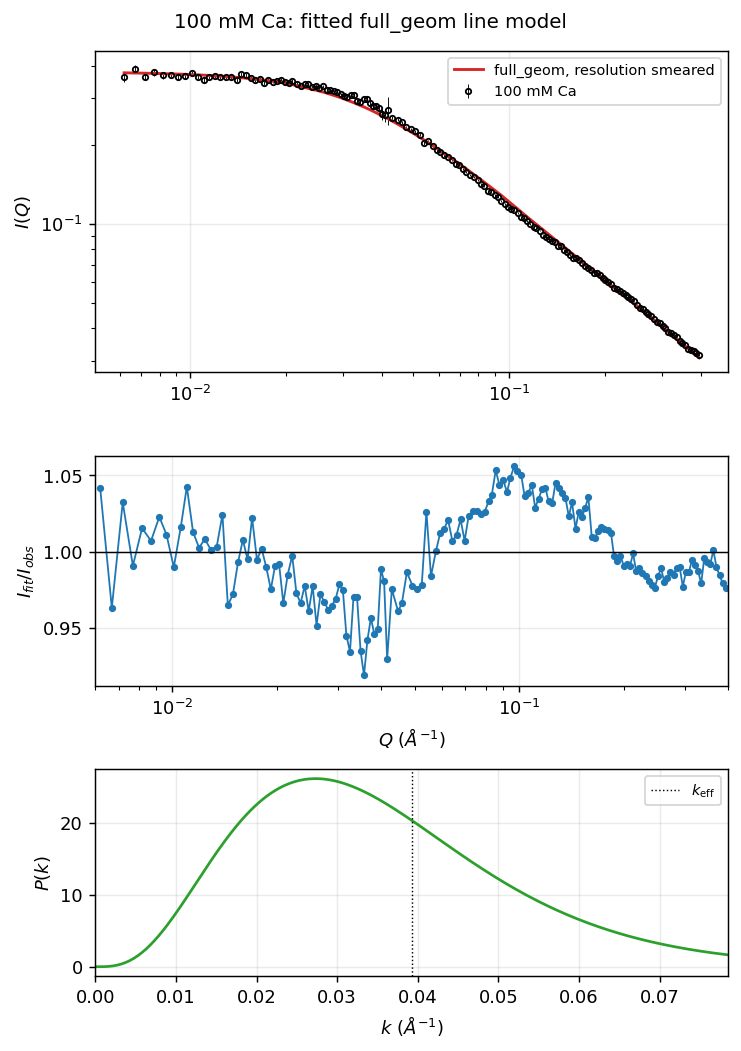

[batch figure] saved output\ca_aniso\ca_100mM_line_only_gamma_radial_unguided_gamma_radial_full_geom_OH2_fit.png
[batch result] success=True, cost=56.7258, k_eff=0.0392385, r_sigma_k=0.477811, stretch=2.20921

[batch] completed 2/2 attempted fits


In [9]:
# Optional continuation fit for every other loaded salt curve.
# The single-curve blocks above remain unchanged and can still be run independently.
RUN_ALL_FITS = True
BATCH_SERIES_SELECTION = ["70mM", "100mM"]  # "all" or, for example, ["D2O", "10mM", "24mM"]
BATCH_FIXED_PARAMETERS = [
    # ("k_eff", 0.05241129),
    # ("r_sigma_k", 0.20),
    # ("stretch_ratio", 1.30),
]
BATCH_MAX_NFEV = MAX_NFEV
BATCH_STRETCH_INITIAL = 1.3
BATCH_STRETCH_BOUNDS = (1.0, 3.00)
BATCH_SALT_MAX_EXCLUSIVE_MILLIMOLAR = None  # fit only salt <15 mM; set None to fit all
BATCH_WIDTH_FACTOR_BOUNDS = (0.5, 2.0)  # relative to each profile's scaled SVD seed; must bracket 1
BATCH_WIDTH_ABSOLUTE_BOUNDS = (0.03, 1.20)
if not BATCH_WIDTH_FACTOR_BOUNDS[0] < 1.0 < BATCH_WIDTH_FACTOR_BOUNDS[1]:
    raise ValueError('BATCH_WIDTH_FACTOR_BOUNDS must bracket 1 so the scaled SVD seed is feasible')
batch_selection = tuple(str(key) for key in BATCH_SERIES_SELECTION)
if not batch_selection:
    raise ValueError('BATCH_SERIES_SELECTION cannot be empty')
if 'all' in batch_selection:
    if batch_selection != ('all',):
        raise ValueError("Use ['all'] alone, or list individual series keys")
    selected_batch_keys = set(SERIES)
else:
    unknown_batch_keys = sorted(set(batch_selection)-set(SERIES))
    if unknown_batch_keys:
        raise KeyError(f'Unknown batch series {unknown_batch_keys}; choose from {tuple(SERIES)} or use all')
    selected_batch_keys = set(batch_selection)
print('[batch selection]', [key for key in SERIES if key in selected_batch_keys])
batch_fixed_values = {str(name): float(value) for name, value in BATCH_FIXED_PARAMETERS}
if len(batch_fixed_values) != len(BATCH_FIXED_PARAMETERS):
    raise ValueError('BATCH_FIXED_PARAMETERS contains a duplicate parameter name')
unknown_fixed_names = sorted(set(batch_fixed_values)-set(active_names))
if unknown_fixed_names:
    raise KeyError(f'Unknown or inactive fixed batch parameters {unknown_fixed_names}; choose from {tuple(active_names)}')
if any(not np.isfinite(value) for value in batch_fixed_values.values()):
    raise ValueError('Every fixed batch parameter value must be finite')
print('[batch fixed]', batch_fixed_values or 'none')

batch_results = {}
batch_summary = []
if RUN_ALL_FITS:
    # Use the selected/D2O solution as the continuation seed, then fit every series including 0 mM.
    continuation = dict(line_fit.parameters) if RUN_FIT and 'line_fit' in globals() else dict(fit_initial)
    for batch_key, batch_config in SERIES.items():
        if batch_key not in selected_batch_keys:
            continue
        batch_concentration = float(batch_config['concentration_mM'])
        if (BATCH_SALT_MAX_EXCLUSIVE_MILLIMOLAR is not None
                and batch_concentration >= BATCH_SALT_MAX_EXCLUSIVE_MILLIMOLAR):
            print(f"[batch skip] {batch_concentration:g} mM is not below "
                  f"{BATCH_SALT_MAX_EXCLUSIVE_MILLIMOLAR:g} mM")
            continue
        batch_label = f"{batch_config['concentration_mM']:g} mM Ca"
        batch_tag = f"ca_{batch_config['concentration_mM']:g}mM"
        print(f"\n[batch] fitting {batch_label}")
        try:
            batch_table = all_tables[batch_key]
            bq, bi, be, bdq = (np.asarray(batch_table[:, col], dtype=float) for col in range(4))
            batch_good = np.isfinite(bq) & np.isfinite(bi) & np.isfinite(be) & np.isfinite(bdq) & (bq > 0) & (be > 0) & (bdq > 0)
            batch_order = np.argsort(bq[batch_good])
            bq, bi, be, bdq = (array[batch_good][batch_order] for array in (bq, bi, be, bdq))
            batch_profile = cf.RadialProfile(batch_tag, bq, bi, be, np.ones(bq.size, dtype=int))
            batch_q_min = max(float(bq.min()), FIT_Q_MIN)
            batch_q_max = min(float(bq.max()), FIT_Q_MAX)
            batch_highq_bounds = (max(HIGHQ_ANCHOR_MIN, batch_q_min), batch_q_max)
            batch_raw_anchor = cf.fit_highq_line_anchor(batch_profile, batch_highq_bounds, allow_signed_background=True)
            batch_background = batch_raw_anchor.parameters['background'] if SUBTRACT_BG else 0.0
            batch_working = cf.subtract_constant_background(batch_profile, batch_background) if SUBTRACT_BG else batch_profile
            batch_highq_anchor = cf.fit_highq_line_anchor(
                batch_working, batch_highq_bounds, background_max=0.0 if SUBTRACT_BG else None,
            )

            batch_fine_tune_path = None
            batch_svd1_width = None
            if GEOM_FINE_TUNE_ACTIVE:
                batch_fine_tune_path, batch_seed_values = find_spectrum_fit_parameters(
                    batch_tag, batch_concentration
                )
                batch_k_eff_seed = float(batch_seed_values['k_eff'])
                batch_width_seed = float(batch_seed_values['r_sigma_k'])
                batch_stretch_seed = float(batch_seed_values['stretch_ratio'])
            else:
                batch_seed_values = continuation
                batch_k_eff_seed = float(continuation.get('k_eff', PARAMETERS['k_eff']['initial']))
                batch_svd1_width = cf.estimate_k_distribution_width_svd1(
                    batch_working.q,
                    batch_working.intensity,
                    batch_k_eff_seed,
                    q_range=(batch_q_min, batch_q_max),
                    k_distribution=K_DISTRIBUTION,
                )
                batch_width_seed = WIDTH_SEED_MULTIPLIER * batch_svd1_width.r_sigma_k
                batch_stretch_seed = BATCH_STRETCH_INITIAL
            width_lo = max(BATCH_WIDTH_ABSOLUTE_BOUNDS[0], BATCH_WIDTH_FACTOR_BOUNDS[0] * batch_width_seed)
            width_hi = min(BATCH_WIDTH_ABSOLUTE_BOUNDS[1], BATCH_WIDTH_FACTOR_BOUNDS[1] * batch_width_seed)
            if ('r_sigma_k' not in batch_fixed_values
                    and not width_lo < batch_width_seed < width_hi):
                raise ValueError(
                    f"Scaled SVD r_sigma_k seed {batch_width_seed} is outside dynamic bounds {(width_lo, width_hi)}"
                )

            batch_initial = {
                'k_eff': batch_k_eff_seed,
                'r_sigma_k': batch_width_seed,
                'stretch_ratio': batch_stretch_seed,
            }
            batch_bounds = {
                'k_eff': tuple(map(float, PARAMETERS['k_eff']['bounds'])),
                'r_sigma_k': (width_lo, width_hi),
                'stretch_ratio': BATCH_STRETCH_BOUNDS,
            }
            batch_fixed = {}
            if CF_MODEL_MODE == 'heterogeneous':
                for name in ('k_H_over_k', 'b'):
                    batch_initial[name] = float(batch_seed_values.get(name, PARAMETERS[name]['initial']))
                    batch_bounds[name] = tuple(map(float, PARAMETERS[name]['bounds']))
                    if PARAMETERS[name]['fixed']:
                        batch_fixed[name] = batch_initial[name]
            if 'r_sigma_k' in batch_fixed_values:
                batch_bounds['r_sigma_k'] = tuple(map(float, BATCH_WIDTH_ABSOLUTE_BOUNDS))
            for name, fixed_value in batch_fixed_values.items():
                batch_initial[name] = fixed_value
                batch_fixed[name] = fixed_value
            for name, value in batch_initial.items():
                lower, upper = map(float, batch_bounds[name])
                if not lower <= float(value) <= upper:
                    raise ValueError(
                        f"Batch initial/fixed {name}={value} is outside bounds {(lower, upper)}"
                    )
            batch_constraints = BASE_FIT_CONSTRAINTS.with_fixed_parameters(batch_fixed)
            batch_distribution_set = {
                'r_sigma_k': {
                    'initial': batch_initial['r_sigma_k'],
                    'bounds': batch_bounds['r_sigma_k'],
                },
            }
            if GEOM_FINE_TUNE_ACTIVE:
                print(f"[batch geometric fine tune] source={batch_fine_tune_path}")
                print(f"[batch seed] k_eff={batch_k_eff_seed:.6g}, r_sigma_k={batch_width_seed:.6g}, "
                      f"bounds=({width_lo:.6g}, {width_hi:.6g}), "
                      f"stretch={batch_stretch_seed:.6g} in {BATCH_STRETCH_BOUNDS}")
            else:
                print(f"[batch seed] k_eff={batch_k_eff_seed:.6g}, "
                      f"SVD1 r_sigma_k={batch_svd1_width.r_sigma_k:.6g}, "
                      f"scaled initial={batch_width_seed:.6g}, "
                      f"bounds=({width_lo:.6g}, {width_hi:.6g}), "
                      f"stretch={batch_stretch_seed:.3g} in {BATCH_STRETCH_BOUNDS}")
            if batch_fixed:
                print('[batch fixed values]', batch_fixed)

            batch_fit = cf.fit_heterogeneous_line_least_squares(
                batch_working, q_bounds=(batch_q_min, batch_q_max), initial=batch_initial,
                model_mode=CF_MODEL_MODE, resolution_sigma=bdq if SMEAR_MODEL else None,
                regression_weights=np.ones_like(bq), lowq_kappa_anchor=None,
                highq_coefficient_anchor=batch_highq_anchor.parameters['coefficient'],
                bounds=batch_bounds, model_settings=fit_model_settings,
                distribution_parameter_set=batch_distribution_set, constraints=batch_constraints,
                max_nfev=BATCH_MAX_NFEV, anchor_weight=HIGHQ_ANCHOR_WEIGHT,
                log_error_floor=LOG_ERROR_FLOOR, affine_stretch=True,
            )
            batch_fit.parameters['feature_wavelength_A'] = 2 * np.pi / batch_fit.parameters['k_eff']
            batch_fit.parameters['salt_concentration_mM'] = float(batch_config['concentration_mM'])
            batch_results[batch_key] = batch_fit
            continuation = dict(batch_fit.parameters)
            batch_components_path = save_affine_geometric_components(
                batch_fit,
                OUTPUT_DIR / f"{batch_tag}_{FIT_VARIANT_TAG}_fit_components.npz",
            )

            parameter_path = OUTPUT_DIR / f"{batch_tag}_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_parameters.csv"
            with parameter_path.open('w', newline='', encoding='utf-8') as handle:
                writer = csv.writer(handle); writer.writerow(['name', 'value']); writer.writerows(batch_fit.parameters.items())
            np.savetxt(
                OUTPUT_DIR / f"{batch_tag}_{K_DISTRIBUTION}_{FIT_GUIDANCE_TAG}_fit_curve.csv",
                np.column_stack([batch_fit.q, batch_fit.intensity, batch_fit.error, batch_fit.model, batch_fit.model / batch_fit.intensity]),
                delimiter=',', header='Q,I_obs,err,I_fit_smeared,I_fit_smeared_over_I_obs', comments='',
            )

            # Save this diagnostic immediately, before moving to the next curve.
            batch_k_fit, batch_p_k_fit = selected_radial_k_density(
                batch_fit.parameters['k_eff'], batch_fit.parameters['r_sigma_k']
            )
            batch_figure_path = OUTPUT_DIR / f"{batch_tag}_{FIT_VARIANT_TAG}_fit.png"
            batch_fig, batch_axes = plt.subplots(3, 1, figsize=(5.8, 8.2), gridspec_kw={'height_ratios': [1.4, 1.0, 0.9]})
            batch_axes[0].errorbar(batch_fit.q, batch_fit.intensity, yerr=batch_fit.error, fmt='o', ms=3, lw=0.5, color='k', markerfacecolor='none', label=batch_label)
            batch_axes[0].plot(batch_fit.q, batch_fit.model, color='C3', lw=1.6, label=f'{STRETCH_MODEL}, resolution smeared')
            batch_axes[0].set(xscale='log', yscale='log', ylabel=r'$I(Q)$')
            batch_axes[0].legend(fontsize=8)
            batch_axes[1].semilogx(batch_fit.q, batch_fit.model / batch_fit.intensity, 'o-', ms=3, lw=1)
            batch_axes[1].axhline(1.0, color='k', lw=0.8)
            batch_axes[1].set(xlabel=r'$Q$ ($\AA^{-1}$)', ylabel=r'$I_{fit}/I_{obs}$', xlim=(batch_q_min, batch_q_max))
            batch_axes[2].plot(batch_k_fit, batch_p_k_fit, color='C2', lw=1.5)
            batch_axes[2].axvline(batch_fit.parameters['k_eff'], color='k', lw=0.8, ls=':', label=r'$k_{\rm eff}$')
            batch_axes[2].set(xlabel=r'$k$ ($\AA^{-1}$)', ylabel=r'$P(k)$', xlim=(0.0, 2.0 * batch_fit.parameters['k_eff']))
            batch_axes[2].legend(fontsize=8)
            batch_fig.suptitle(f'{batch_label}: fitted {STRETCH_MODEL} line model', fontsize=11)
            batch_fig.tight_layout()
            batch_fig.savefig(batch_figure_path, dpi=200, bbox_inches='tight')
            plt.show()
            plt.close(batch_fig)
            print(f"[batch figure] saved {batch_figure_path}")
            batch_summary.append({
                'series': batch_key, 'concentration_mM': batch_config['concentration_mM'],
                'success': batch_fit.success, 'cost': batch_fit.cost, 'nfev': batch_fit.nfev,
                'r_sigma_k_svd1': (np.nan if batch_svd1_width is None else batch_svd1_width.r_sigma_k),
                'r_sigma_k_seed': batch_width_seed,
                'fine_tune_source': ('' if batch_fine_tune_path is None else str(batch_fine_tune_path)),
                'r_sigma_k_bound_low': width_lo, 'r_sigma_k_bound_high': width_hi,
                'k_eff': batch_fit.parameters['k_eff'], 'r_sigma_k': batch_fit.parameters['r_sigma_k'],
                'stretch_ratio': batch_fit.parameters['stretch_ratio'], 'figure': str(batch_figure_path),
                'message': batch_fit.message,
            })
            print(f"[batch result] success={batch_fit.success}, cost={batch_fit.cost:.6g}, "
                  f"k_eff={batch_fit.parameters['k_eff']:.6g}, r_sigma_k={batch_fit.parameters['r_sigma_k']:.6g}, "
                  f"stretch={batch_fit.parameters['stretch_ratio']:.6g}")
        except Exception as exc:
            batch_summary.append({'series': batch_key, 'concentration_mM': batch_config['concentration_mM'], 'success': False, 'message': repr(exc)})
            print(f"[batch error] {batch_label}: {exc}")

    summary_fields = sorted({field for row in batch_summary for field in row})
    with (OUTPUT_DIR / 'ca_all_salt_fit_summary.csv').open('w', newline='', encoding='utf-8') as handle:
        writer = csv.DictWriter(handle, fieldnames=summary_fields); writer.writeheader(); writer.writerows(batch_summary)
    print(f"\n[batch] completed {len(batch_results)}/{len(batch_summary)} attempted fits")
else:
    print('[batch] RUN_ALL_FITS=False; the existing selected-curve workflow is unchanged')
